In [114]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import folium
from folium.plugins import DualMap
from folium.plugins import pattern
from folium.elements import MacroElement
import branca.colormap as cm
from branca.element import Element

In [115]:
gdf = gpd.read_file("data/louisiana/louisiana2026.geojson")

# EPSG must be set to 4326 for folium
print(gdf.crs)
gdf = gdf.to_crs("EPSG:4326")

gdf.head(6)

EPSG:4269


,District No.,District,Harris 26 Votes,Trump 26 Votes,Harris New %,Trump New %,Margin New,Margin New %,Harris 24,Trump 24,...,Harris %,Trump %,Margin 24,Margin %,Margin Shift,Margin Shift %,Targeted,Shape Area,Shape Length,geometry
0,1,LA01,102921,234279,0.305222,0.694778,-0.389555,-38.96%,111933,252925,...,30.11%,68.03%,-0.3792,-37.92%,-0.010355,-1.04%,False,2.206914,13.249303,"POLYGON ((-90.25170 30.71172, -90.24707 30.710..."
1,2,LA02,217199,74397,0.744863,0.255137,0.489726,48.97%,207309,106781,...,64.72%,33.33%,0.3138,31.38%,0.175926,17.59%,False,0.283721,7.248457,"POLYGON ((-91.16473 30.58425, -91.16444 30.584..."
2,3,LA03,104323,223456,0.318272,0.681728,-0.363455,-36.35%,90504,240932,...,26.94%,71.71%,-0.4478,-44.78%,0.084345,8.43%,False,2.311270,11.137485,"POLYGON ((-91.78509 30.69264, -91.78492 30.692..."
3,4,LA04,102243,206563,0.331091,0.668909,-0.337817,-33.78%,78541,254091,...,23.33%,75.47%,-0.5214,-52.14%,0.183583,18.36%,False,3.271381,15.821837,"POLYGON ((-93.90428 33.01957, -93.90115 33.019..."
4,5,LA05,101495,206180,0.329877,0.670123,-0.340245,-34.02%,104074,225375,...,31.12%,67.39%,-0.3627,-36.27%,0.022455,2.25%,False,3.776345,19.782514,"POLYGON ((-92.04496 33.00775, -92.03709 33.007..."
5,6,LA06,112747,220706,0.338120,0.661880,-0.323761,-32.38%,174508,128401,...,56.71%,41.73%,0.1498,14.98%,-0.473561,-47.36%,True,0.952098,11.739631,"POLYGON ((-91.66845 31.00815, -91.66628 31.006..."


In [116]:
# Create new columns that shows partisan lean (e.g. D+7.89) for visualization
def partisan_text(val):
    if val is None or str(val).strip() in ['', 'nan', 'None']:
        return "EVEN"
        
    try:
        clean_val = str(val).replace('%', '').strip()
        num = float(clean_val)
        
        if num < 0:
            return f"Trump+{abs(num):.2f}".rstrip('0').rstrip('.')
            
        elif num > 0:
            return f"Harris+{num:.2f}".rstrip('0').rstrip('.')
            
        return "EVEN"
    except ValueError:
        return str(val)

gdf['Margin Partisan'] = gdf['Margin %'].apply(partisan_text)
gdf['Margin New Partisan'] = gdf['Margin New %'].apply(partisan_text)
gdf['Margin Shift Partisan'] = gdf['Margin Shift %'].apply(partisan_text)

gdf.head(6)

,District No.,District,Harris 26 Votes,Trump 26 Votes,Harris New %,Trump New %,Margin New,Margin New %,Harris 24,Trump 24,...,Margin %,Margin Shift,Margin Shift %,Targeted,Shape Area,Shape Length,geometry,Margin Partisan,Margin New Partisan,Margin Shift Partisan
0,1,LA01,102921,234279,0.305222,0.694778,-0.389555,-38.96%,111933,252925,...,-37.92%,-0.010355,-1.04%,False,2.206914,13.249303,"POLYGON ((-90.25170 30.71172, -90.24707 30.710...",Trump+37.92,Trump+38.96,Trump+1.04
1,2,LA02,217199,74397,0.744863,0.255137,0.489726,48.97%,207309,106781,...,31.38%,0.175926,17.59%,False,0.283721,7.248457,"POLYGON ((-91.16473 30.58425, -91.16444 30.584...",Harris+31.38,Harris+48.97,Harris+17.59
2,3,LA03,104323,223456,0.318272,0.681728,-0.363455,-36.35%,90504,240932,...,-44.78%,0.084345,8.43%,False,2.311270,11.137485,"POLYGON ((-91.78509 30.69264, -91.78492 30.692...",Trump+44.78,Trump+36.35,Harris+8.43
3,4,LA04,102243,206563,0.331091,0.668909,-0.337817,-33.78%,78541,254091,...,-52.14%,0.183583,18.36%,False,3.271381,15.821837,"POLYGON ((-93.90428 33.01957, -93.90115 33.019...",Trump+52.14,Trump+33.78,Harris+18.36
4,5,LA05,101495,206180,0.329877,0.670123,-0.340245,-34.02%,104074,225375,...,-36.27%,0.022455,2.25%,False,3.776345,19.782514,"POLYGON ((-92.04496 33.00775, -92.03709 33.007...",Trump+36.27,Trump+34.02,Harris+2.25
5,6,LA06,112747,220706,0.338120,0.661880,-0.323761,-32.38%,174508,128401,...,14.98%,-0.473561,-47.36%,True,0.952098,11.739631,"POLYGON ((-91.66845 31.00815, -91.66628 31.006...",Harris+14.98,Trump+32.38,Trump+47.36


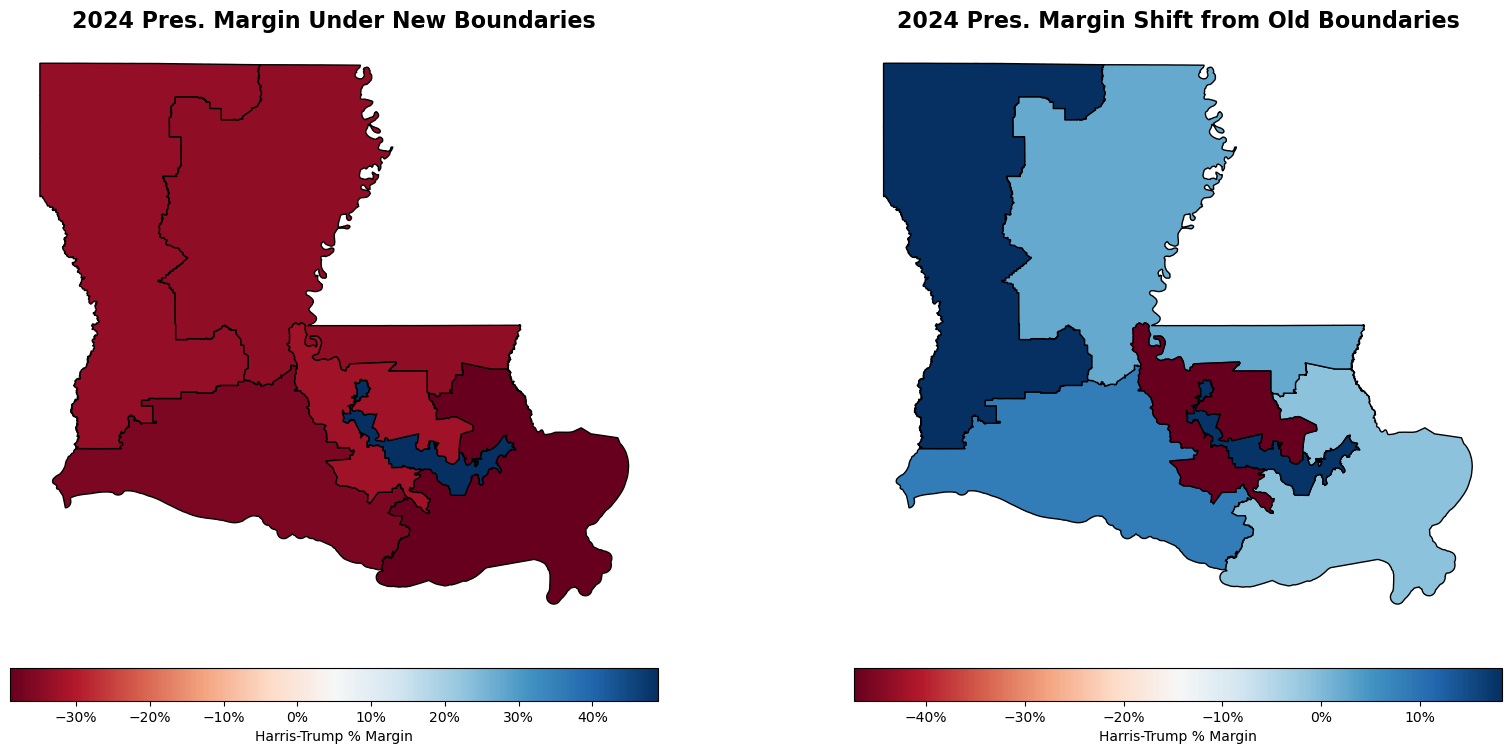

In [117]:
# Test data visualization with matplotlib
# Plot 2024 Pres. margin and shift under new maps 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

gdf.plot(
    column='Margin New', 
    cmap='RdBu',            
    legend=True,              
    legend_kwds={'label': 'Harris-Trump % Margin',
                 'orientation': 'horizontal',
                 'shrink': 0.7,
                 'pad': 0.05},
    edgecolor='black',        
    ax=ax1
)

ax1.axis('off')
ax1.set_title(
    "2024 Pres. Margin Under New Boundaries", 
    fontsize=16, 
    fontweight='bold'
)

# Change legend markers to percentage
fig.axes[-1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

gdf.plot(
    column='Margin Shift',      
    cmap='RdBu',           
    legend=True,              
    legend_kwds={'label': 'Harris-Trump % Margin',
                 'orientation': 'horizontal',
                 'shrink': 0.7,
                 'pad': 0.05},
    edgecolor='black',        
    ax=ax2
)

ax2.axis('off')
ax2.set_title(
    "2024 Pres. Margin Shift from Old Boundaries",
    fontsize=16,
    fontweight='bold'
) 

fig.axes[-1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plt.tight_layout()
plt.show()

In [118]:
# Initiate dual maps for folium
m = DualMap(location=[31.0, -92.0], zoom_start=7, tiles="CartoDB positron")

# Set minimum and maximum zoom distance
for sub_map in [m.m1, m.m2]:
    sub_map.options['minZoom'] = 6
    sub_map.options['maxZoom'] = 8

In [119]:
# Define styling for targeted districts
hatch_pattern = pattern.StripePattern(
    angle=-45,
    color='black',
    space_color='transparent',
    weight=3,
    space_weight=5
).add_to(m)

# Define function for hatch styling to avoid browser ordering issues when rendering
def style_hatch(feature):
    targeted = feature['properties'].get('Targeted', False)
    if targeted:
        return {'fillPattern': hatch_pattern, 'fillOpacity': 0.6, 'color': 'transparent'}
    return {'fillColor': 'transparent', 'color': 'transparent'}

In [120]:
# Color scheme for partisan lean of new districts
def style_left(feature):
    margin = feature['properties'].get('Margin New', 0)
    
    if margin >= 0.30:     color = '#084594'  
    elif margin >= 0.15:   color = 'steelblue'  
    elif margin > 0:       color = 'lightblue' 
    elif margin >= -0.15:  color = 'lightcoral' 
    elif margin >= -0.30:  color = 'tomato'  
    else:                  color = 'firebrick' 
        
    style_dict = {
        'fillColor': color,
        'color': 'black',   
        'weight': 1,
        'fillOpacity': 0.8
    }
        
    return style_dict

# Color scheme for partisan shift for new boundaries
def style_right(feature):
    margin = feature['properties'].get('Margin Shift', 0)
    
    if margin >= 0.30:     color = '#084594'  
    elif margin >= 0.15:   color = 'steelblue'  
    elif margin > 0:       color = 'lightblue' 
    elif margin >= -0.15:  color = 'lightcoral' 
    elif margin >= -0.30:  color = 'tomato'  
    else:                  color = 'firebrick' 
        
    style_dict = {
        'fillColor': color,
        'color': 'black',   
        'weight': 1,
        'fillOpacity': 0.8
    }
        
    return style_dict

In [121]:
# Tooltip styling
tooltip_left = folium.GeoJsonTooltip(
    fields=['District No.', 'Margin New Partisan'], 
    aliases=['New District:', '2024 Presidential Margin:'],
    style=(
        "background-color: rgba(255, 255, 255, 0.95); "  
        "color: #1a1a1a; "                               
        "font-size: 12px; "                              
        "font-weight: bold; "
        "border: 2px solid #222222; "                    
        "box-shadow: 3px 3px 10px rgba(0,0,0,0.25);"     
    ),
    localize=True
)

tooltip_right = folium.GeoJsonTooltip(
    fields=['District No.', 'Margin Shift Partisan', 'Margin Partisan'], 
    aliases=['New District:', "Shift from Old District's Margin:", "Old District's 2024 Margin:"],
    style=(
        "background-color: rgba(255, 255, 255, 0.95); "
        "color: #1a1a1a; "
        "font-size: 12px; "
        "font-weight: bold; "
        "border: 2px solid #222222; "
        "border-radius: 4px; "
        "box-shadow: 3px 3px 10px rgba(0,0,0,0.25);"
    ),
    localize=True
)

# Make the 3rd field in the shift map tooltip normal font to indicate less importance
normal_font = """
<style>
.leaflet-tooltip tr:nth-child(3) th,
.leaflet-tooltip tr:nth-child(3) td {
    font-weight: normal !important;
}
</style>
"""

# Append the above font rule to the map head layout
m.get_root().header.add_child(folium.Element(normal_font))

In [122]:
# Bind maps and their styling schemes
folium.GeoJson(
    gdf,
    style_function=style_left,
).add_to(m.m1)

folium.GeoJson(
    gdf,
    style_function=style_hatch,
    tooltip=tooltip_left
).add_to(m.m1)

folium.GeoJson(
    gdf,
    style_function=style_right,
).add_to(m.m2)

folium.GeoJson(
    gdf,
    style_function=style_hatch,
    tooltip=tooltip_right
).add_to(m.m2)

# Put city labels on the top layer
pane_left = folium.map.CustomPane("labels_left", z_index=450).add_to(m.m1)
pane_right = folium.map.CustomPane("labels_right", z_index=450).add_to(m.m2)

folium.TileLayer("cartodbpositrononlylabels", pane="labels_left").add_to(m.m1)
folium.TileLayer("cartodbpositrononlylabels", pane="labels_right").add_to(m.m2)

In [123]:
# Instantiate a legend
bounds = [-0.45, -0.30, -0.15, 0.0, 0.15, 0.30, 0.45]
colors = ['firebrick', 'tomato', 'lightcoral', 'lightblue', 'steelblue', '#084594']

legend = cm.StepColormap(
    colors=colors,
    index=bounds,
    vmin=-0.45,
    vmax=0.45,
    caption="Harris-Trump Margin / Margin Shift (Striped = Redistricted to Flip)"
)

legend.caption_steps = bounds 
# legend.width = 420

# Custom CSS for legend styling
m.get_root().header.add_child(folium.Element("""
<style>
    /* Container */
    .legend {
        background-color: white !important;        
        border: 1px solid #222222 !important;       
        border-radius: 5px !important;              
        padding: 3px !important;
    }
    /* Title */
    .legend .caption {
        color: black !important;                  
        font-size: 12px !important;
    }
    /* Ticks */
    .legend text {
        fill: black !important;                   
        font-size: 10px !important;
    }
</style>
"""))

# javascript to convert ticks from decimals to percentages
# percentage_formatter_js = """
# <script>
# document.addEventListener("DOMContentLoaded", function() {
#     var ticks = document.querySelectorAll('div.legend g.tick text');
    
#     for (var i = 0; i < ticks.length; i++) {
#         var rawValue = parseFloat(ticks[i].textContent);
        
#         if (!isNaN(rawValue)) {
#             var percentageValue = Math.round(rawValue * 100) + '%';
            
#             if (rawValue === 0) { 
#                 percentageValue = '0%'; 
#             }
#             else if (rawValue > 0) { 
#                 percentageValue = '+' + percentageValue; 
#             }
            
#             ticks[i].textContent = percentageValue;
#         }
#     }
# });
# </script>
# """
# m.get_root().html.add_child(folium.Element(percentage_formatter_js))

# The semicolon prevents automatic visual rendering; alternatively, assign this to a dummy variable
m.m1.add_child(legend);

m.save("louisiana.html")
m